In [50]:
import os
import numpy as np
import scipy.ndimage
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from mt_DIDC_config import GROUPING_RULES


In [9]:
class offsetNet(nn.Module):
    def __init__(self, target_size=(384, 384)):
        super(offsetNet, self).__init__()
        self.offsets = nn.Parameter(torch.zeros(1, 3, target_size[0], target_size[1])) 
        self.scale_param = nn.Parameter(torch.zeros(1))

    def forward(self):
        return self.offsets, torch.tanh(self.scale_param)

In [ ]:
class PropertyGenerator:
    def __init__(self, device=None, epochs=500, lr=0.001, patience=50, min_delta=1e-4, properties_key: dict = None, label2label: dict = None, label2idx: list = None, label2label_old: dict = None):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device
            
        self.epochs = epochs
        self.lr = lr

        self.PD_max, self.T1_max, self.T2_max = 200., 2000., 500.

        self.TR = 3.0
        self.TE = 1.5
        self.flip_angle = 0.6

        self.patience = patience
        self.min_delta = min_delta
        
        self.properties_keys = properties_key
        self.label2idx = label2idx
        self.label2label = {old_label: label2label[new_label] for old_label, new_label in label2label_old.items()} # mapping from old labels to the final labels (skipping the "new" 22 label step)

    def _initialize_tissue_maps(self, mask):
        """Creates initial tissue starting from the mask"""
        h, w = mask.shape
        init_prop = np.zeros((1, 3, h, w), dtype=np.float32)
        
        for old_label, new_label in self.label2label.items():
            ix, iy = np.where(mask == self.label2idx.index(old_label))
            if len(ix) > 0:
                init_prop[0, 0, ix, iy] = self.properties_keys[new_label][0] / self.PD_max
                init_prop[0, 1, ix, iy] = self.properties_keys[new_label][1] / self.T1_max
                init_prop[0, 2, ix, iy] = self.properties_keys[new_label][2] / self.T2_max
                
        return torch.tensor(init_prop, dtype=torch.float32, device=self.device)

    def _bssfp_signal_model(self, offsets, init_values):
        """bSSFP physical simulator"""
        # Sums offsets with initial values, clamps to range, and rescales to physical units
        PD = torch.clamp(offsets[:, 0, ...] + init_values[:, 0, ...], 0.001, 50) * self.PD_max
        T1 = torch.clamp(offsets[:, 1, ...] + init_values[:, 1, ...], 0.001, 50) * self.T1_max
        T2 = torch.clamp(offsets[:, 2, ...] + init_values[:, 2, ...], 0.001, 50) * self.T2_max
        
        num = PD * np.sin(self.flip_angle)
        den = (T1 / T2 + 1) - np.cos(self.flip_angle) * (T1 / T2 - 1)
        decay = torch.exp(-self.TE / T2)
        
        m = torch.abs((num / den) * decay) * 0.05
        return m

    def _loss_fn(self, target_img, predicted_img, offset):
        """Error computation with L2 regularization on tissue property offsets."""
        PD_offset, T1_offset, T2_offset = offset[:, 0, ...], offset[:, 1, ...], offset[:, 2, ...]
        
        recon_error = torch.mean((predicted_img - target_img)**2)
        # Regolarizzazione L2: penalizza pesantemente le variazioni di PD
        tissue_reg = torch.mean(PD_offset**2) * 10000 + 0.1 * torch.mean(T1_offset**2) + 0.01 * torch.mean(T2_offset**2)
        
        return recon_error + (tissue_reg * 0.001)

    def fit_slice(self, mri_slice, label_slice):
        """Actual optimization for a single 2D slice."""
        target_size = mri_slice.shape
        target_image = torch.tensor(mri_slice, dtype=torch.float32, device=self.device)
        init_tissue_properties = self._initialize_tissue_maps(label_slice)
        
        # Inizializza la rete con le dimensioni dinamiche della fetta
        onet = offsetNet(target_size=target_size).to(self.device)
        optimizer = optim.Adam(onet.parameters(), lr=self.lr)

        onet.train()
        epoch_iter = tqdm(range(self.epochs), desc='Fitting Slice', leave=False)
        
        best_loss = float('inf')
        epochs_no_improve = 0

        for epoch in epoch_iter:
            optimizer.zero_grad()
            
            tissue_offsets, scale_mag = onet()
            predicted_img = self._bssfp_signal_model(tissue_offsets, init_tissue_properties) * (1 + scale_mag)
            
            loss = self._loss_fn(target_image, predicted_img, tissue_offsets)
            loss.backward()
            optimizer.step()

            if loss.item() < best_loss - self.min_delta:
                best_loss = loss.item()
                epochs_no_improve = 0
                best_offsets = tissue_offsets
                best_scale = scale_mag
            else:
                epochs_no_improve += 1
            
            if epochs_no_improve >= self.patience:
                print(f"Early stopping at epoch {epoch+1} with best loss {best_loss:.4g}")
                tissue_offsets = best_offsets
                scale_mag = best_scale
                break
            
            if epoch % 50 == 0:
                epoch_iter.set_postfix_str("loss=%.4g" % loss.item())
                
        final_offsets = tissue_offsets.detach()
        final_scale = scale_mag.detach()
        
        final_props = torch.zeros_like(final_offsets)
        final_props[0, 0] = torch.clamp(final_offsets[0, 0] + init_tissue_properties[0, 0], 0.001, 50) * self.PD_max
        final_props[0, 1] = torch.clamp(final_offsets[0, 1] + init_tissue_properties[0, 1], 0.001, 50) * self.T1_max
        final_props[0, 2] = torch.clamp(final_offsets[0, 2] + init_tissue_properties[0, 2], 0.001, 50) * self.T2_max
        
        return final_props[0].cpu().numpy(), predicted_img[0].detach().cpu().numpy(), init_tissue_properties[0].cpu().numpy(), final_scale.detach().cpu().numpy()

    def process_volume(self, mri_volume, labels_volume, out_path, upsample_factor=4):
        """Handles the entire 3D volume: Upsampling, Fitting slice by slice, and Saving."""
        print("Upsampling images...")
        mri_hd = scipy.ndimage.zoom(mri_volume, (1, upsample_factor, upsample_factor), order=1)
        labels_hd = scipy.ndimage.zoom(labels_volume, (1, upsample_factor, upsample_factor), order=0)
        
        slices, h, w = mri_hd.shape
        tissue_props = np.zeros((slices, 3, h, w), dtype=np.float32)
        
        if not os.path.exists(os.path.join(out_path, 'images')):
            os.makedirs(os.path.join(out_path, 'images'))

        for s in range(slices):
            print(f"Processing Slice {s+1}/{slices}")
            # Executes optimization
            props, pred_img, init_props, scale = self.fit_slice(mri_hd[s], labels_hd[s])
            tissue_props[s] = props
            
            if s % 20 == 0 or s == 0:
                fig, ax = plt.subplots(1, 2, figsize=(10, 5))
                ax[0].imshow(mri_hd[s], cmap='gray')
                ax[0].set_title("Real MRI")
                ax[1].imshow(pred_img, cmap='gray')
                ax[1].set_title("Simulated bSSFP")
                plt.savefig(os.path.join(out_path, f'images/MRI_{s:05d}.png'), dpi=150)
                plt.close()
                
        print("\nSaving matrices...")
        np.save(os.path.join(out_path, 'Max_values.npy'), [self.PD_max, self.T1_max, self.T2_max])
        np.save(os.path.join(out_path, 'MRI_matrix_HD.npy'), mri_hd)
        np.save(os.path.join(out_path, 'labels_matrix_HD.npy'), labels_hd)
        np.save(os.path.join(out_path, 'tissue_props.npy'), tissue_props)
        print("Done!")



In [246]:
if __name__ == "__main__":
    torch.set_default_dtype(torch.float32)
    
    data_path = ''
    

    MRI_orig = np.load(os.path.join(data_path, 'MRI_matrix_orig.npy')) # garyscale MR images
    labels_orig = np.load(os.path.join(data_path, 'labels_matrix_orig.npy')) # multi tissue mask useful for initialization of base properties
    
    generator = PropertyGenerator(epochs=500, lr=0.001)
    
    # Lancia l'elaborazione dell'intero volume
    generator.process_volume(MRI_orig, labels_orig, out_path=data_path, upsample_factor=4)

FileNotFoundError: [Errno 2] No such file or directory: 'MRI_matrix_orig.npy'

In [247]:
# ITIS database values for reference
my_properties_key = {
    "blood": [80.43, 1414.8, 308.5],  # (ITIS)
    "bone": [15.30, 288.0, 165.0], # (ITIS yellow marrow)
    "muscle": [76.21, 981.5, 36.0], # (ITIS)
    "fat": [100., 288.0, 165.0],  # (Gold et al. 2012, subcutaneous fat)
    "heart_muscle": [79.47, 1026.3, 42.0],  # (ITIS)
    "liver": [76.33, 661.5, 56.8],  # (ITIS)
    "lungs": [27.20, 1196., 6.3],  # (ITIS, T1 is from Dietrich et al 2016)
    "pancreas": [73.18, 584.0, 46.0], # (ITIS)
    "spleen": [79.34, 1057.0, 79.0], # (ITIS)
    "kidney": [80.50, 828.0,  71.0], # (ITIS)
    "spinal_cord": [71.84, 745.0, 74.0], # (ITIS)
    "skin": [65.19, 900.0, 20.0], # (ITIS, T1 and T2 are estimated from derma values in Richard et al, 1991)
    "others": [71.0, 250.0, 20.0], # from Buoso
    "background_air": [65.0, 750.0, 60.0], # from Buoso
    "trachea": [60.00, 1045.5, 37.3]
}

# "cartilage": [71.77, 1045.5, 37.3], # (ITIS)


label2label = {
    "Aorta": "blood",
    "Background": "background_air",
    "Blood_vessels": "blood",
    "Bones_and_cartilage": "bone",
    "Esophagus_and_trachea": "trachea",
    "Fat": "fat",
    "Gallbladder": "others",
    "Heart_generic": "heart_muscle",
    "Intestine": "others",
    "Kidneys": "kidney",
    "LV_Myocardium": "heart_muscle",
    "LV_blood_pool": "blood",
    "Liver": "liver",
    "Lungs": "lungs",
    "Muscle": "muscle",
    "Others": "others",
    "Pancreas": "pancreas",
    "RV_blood_pool_myocardium": "heart_muscle",
    "Skin": "skin",
    "Spinal_cord": "spinal_cord",
    "Spleen": "spleen",
    "Stomach": "muscle",
}





In [248]:
data_dir = 'DIDC_multiclass_coro_v2'


In [249]:
def load_original_labels(data_path):
    original_labels = []

    if os.path.isfile(data_path + '/tissue_list.txt'):
        with open (data_path + '/tissue_list.txt', 'r') as f:
            for i, line in enumerate(f):
                if i > 1:
                    line = line.strip().split()[-1]
                    original_labels.append(line)
        return ['Background'] + original_labels
    else:
        raise FileNotFoundError(f"Original labels file not found at {data_path + '/tissue_list.txt'}")

In [250]:
label2idx = load_original_labels(data_dir)
label2label_old = GROUPING_RULES

In [251]:
generator = PropertyGenerator(epochs=500, lr=0.001, patience=50, min_delta=1e-4, properties_key=my_properties_key, label2label=label2label, label2idx=label2idx, label2label_old=label2label_old)

In [254]:
files = sorted(os.listdir(data_dir))
rnd_pat_file = files[np.random.randint(0, len(files)-1)]

Original mask shape: (49760000,)
Reshaped mask shape: (400, 400, 311)


Text(0.5, 1.0, 'Modified Mask')

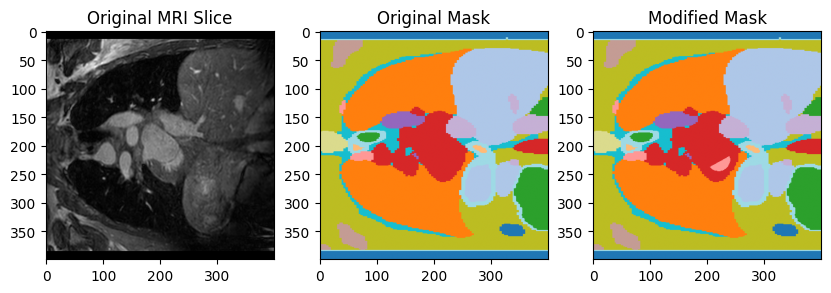

In [255]:
pat = np.load(os.path.join(data_dir, rnd_pat_file), allow_pickle=True).item()

pat_volume = pat['interpolated_intensity']
pat_slice = pat_volume[..., 150]

pat_mtmask = pat['interpolated_segmentation'] 
print("Original mask shape:", pat_mtmask.shape)
pat_mtmask = pat_mtmask.reshape((pat_volume.shape[0], pat_volume.shape[1], -1), order='F') if pat_mtmask.ndim == 1 else pat_mtmask
print("Reshaped mask shape:", pat_mtmask.shape)


pat_fgmask = pat['mask_foreground']
bp_coords = np.where(pat_fgmask == 1)

pat_mtmask_new = pat_mtmask.copy()
pat_mtmask_new[bp_coords] = label2idx.index('Artery_subclavian_right') # it then becomes Blood_vessels label which is mapped to "blood" in the properties generator


fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(pat_slice, cmap='gray')
ax[0].set_title("Original MRI Slice")
ax[1].imshow(pat_mtmask[..., 150], cmap='tab20')
ax[1].set_title("Original Mask")
ax[2].imshow(pat_mtmask_new[..., 150], cmap='tab20')
ax[2].set_title("Modified Mask")

In [256]:
tissue_map = generator._initialize_tissue_maps(pat_mtmask_new[..., 150])
tm = tissue_map[..., 200, 200].cpu().numpy() 
tm

array([[0.39735, 0.51315, 0.084  ]], dtype=float32)

In [257]:
tm * np.array([generator.PD_max, generator.T1_max, generator.T2_max])

array([[  79.47000265, 1026.29995346,   41.99999943]])

In [258]:
rnd_pat_file.replace('.npy', '_fg.npy')

'DIDC-241-T01_multiclass_fg.npy'

In [259]:
outpath = 'test'
os.makedirs(outpath, exist_ok=True)

In [ ]:
generator.process_volume(pat_volume, pat_mtmask_new, out_path=outpath, upsample_factor=1)

Upsampling images...

Processing Slice 1/400


Early stopping at epoch 210 with best loss 4.788e-05

Processing Slice 2/400


Early stopping at epoch 210 with best loss 4.788e-05

Processing Slice 3/400


Early stopping at epoch 210 with best loss 4.788e-05

Processing Slice 4/400


Early stopping at epoch 210 with best loss 4.788e-05

Processing Slice 5/400


...


Processing Slice 62/400



Processing Slice 63/400



Processing Slice 64/400



Processing Slice 65/400


Fitting Slice:  91%|█████████▏| 457/500 [00:03<00:00, 124.27it/s, loss=2.1e+05]  